# CS 135 day 04: Hyperparameter Selection on Val. Set

We will explore *hyperparameter selection* using the new model family we just learned about, Linear Regression with Polynomial Features

# Objectives

* Learn how to compute polynomial features
* Try out selecting the polynomial degree on a fixed validation set

* Learn how to use sklearn's built-in Polynomial feature transformer
* Learn how to use sklearn pipelines to compose useful elementary transformations and predictors


# Takeaways

* Hyperparameter selection is important to avoid overfitting (and underfitting)
* We cannot use the training set alone to select hyperparameters
* We should use a separate validation set to compute the error we use to select hyperparameters (or do cross-validation)
* Sklearn has many built-in features (Pipelines, feature transformers, etc) that make your life easier if you know how to use them well
* * They all follow a standard interface (aka "API")

In [2]:
import numpy as np

# Import the pandas (data management library)
import pandas as pd

In [4]:
# import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

In [5]:
import sklearn.linear_model
import sklearn.pipeline

# Prepare a simple 'sine-wave' dataset

In [6]:
SEED = 12345
prng = np.random.RandomState(SEED)

In [7]:
def true_prediction_function(x):
    return np.sin(2.1 * x)

In [8]:
L = 9        # num training examples (to estimate weight parameters)

x_tr_L = np.linspace(-3, 3, L) + 0.09 * prng.randn(L)
y_tr_L = true_prediction_function(x_tr_L) + 0.3 * prng.randn(L)

In [9]:
N = 15      # num validation examples (to select hyperparameters)

x_va_N = np.linspace(-3.1, 3.1, N)
y_va_N = true_prediction_function(x_va_N) + 0.3 * prng.randn(N)

In [10]:
M = 500      # num testing examples (to show "true" generalization)

x_te_M = np.linspace(-3.5, 3.5, M)
y_te_M = true_prediction_function(x_te_M) + 0.3 * prng.randn(M)

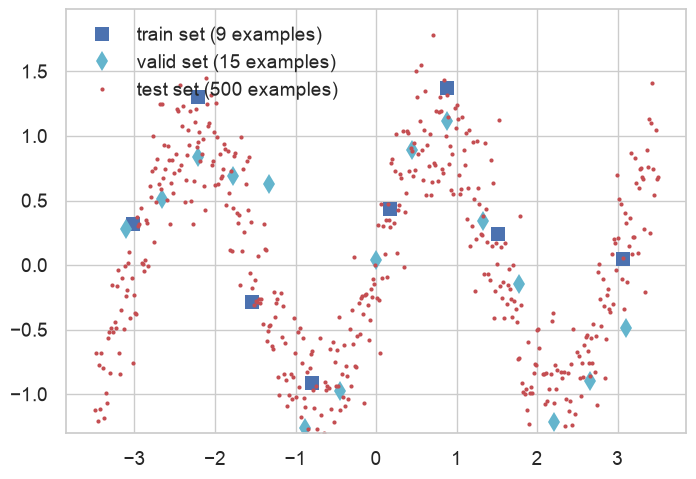

In [11]:
plt.plot(x_tr_L, y_tr_L, 'bs', markersize=10, label='train set (%d examples)' % L)
plt.plot(x_va_N, y_va_N, 'cd', markersize=10, label='valid set (%d examples)' % N)
plt.plot(x_te_M, y_te_M, 'r.', label='test set (%d examples)' % M)

plt.legend(loc='upper left');
plt.ylim([-1.3, 1.98]);

In [12]:
# Reshape all 'x' arrays so they are 2D with shape (n_examples, 1)

x_tr_L1 = x_tr_L[:,np.newaxis]
x_va_N1 = x_va_N[:,np.newaxis]
x_te_M1 = x_te_M[:,np.newaxis]

<a id="part1"></a>

# Linear Regression

First, let's try to fit plain old linear regression to this dataset.

What is the learned slope?

What is the learned intercept/bias value?

### Can you make predictions using the model above on the heldout test set?

In [13]:
yhat_te_M = None #TODO

ValueError: x, y, and format string must not be None

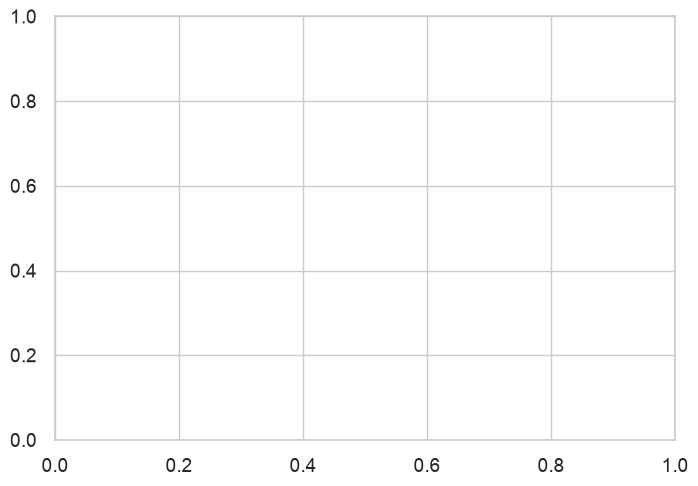

In [14]:
plt.plot(x_te_M, yhat_te_M, 'b.-', label='predictions from LR')
plt.plot(x_tr_L, y_tr_L, 'bs', markersize=10, label='training set')

plt.legend(bbox_to_anchor=(1.0, 0.5))
plt.ylim([-1.5, 1.5]);
plt.xlabel('x');
plt.ylabel('y');

<a id="part2"></a>

# Polynomial Features with sklearn

Given our scalar feature $x_i \in \mathbb{R}$, we want to TRANSFORM it to a $F$-degree polynomial feature vector (of size $F+1$)

$$
\begin{align}
\phi_0(x_i) &= [1]
\\
\phi_1(x_i) &= [1 ~~ x_i]
\\
\phi_2(x_i) &= [1 ~~ x_i ~~ x_i^2]
\\
\phi_3(x_i) &= [1 ~~ x_i ~~ x_i^2 ~~ x_i^3] \\
\vdots \\
\phi_F(x_i) &= [1 ~~ x_i ~~ x_i^2 ~~ x_i^3 ~~ \ldots x_i^F]
\end{align}
$$

And then use these transformed features to do linear regression.

That is, we'll learn weights for each of the entries of the vector produced by $\phi_F$. You write code to do this on homework 1, but here we will use sklearn's build-in packages. You can read details of the implementation here:

<https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features>

Create an array to try things out as input

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

my_x_N1 = np.arange(4).reshape(4, 1)
print("Original Features my_x_N1")
print(my_x_N1)

In [ ]:
poly = PolynomialFeatures(2)
# call 'fit_transform' to perform the transformation
phi_NG = poly.fit_transform(my_x_N1)

print("Transformed Features phi_NG using 2-degree polynomial")
print(phi_NG)

## Exercise 2b

Construct a 5th degree polynomial transform of `x_N1` and make sure its values match what you would expect.

In [ ]:
# TODO
poly = PolynomialFeatures(5)
phi_NG = poly.fit_transform(my_x_N1)

print("Transformed Features phi_NG using 5-degree polynomial")
print(phi_NG)

## Which feature transform to use?

Anything you want for your domain & task!

* sin/cos for periodic data
* polynomials for high-order dependencies
    * $\phi(x_i) = [1 ~~ x_i ~~ x_i^2 ~~ ...]$
* interactions between feature dimensions
    * $\phi(x_i) = [1 ~~ x_{i1}x_{i2} ~~ x_{i1}x_{i3} ~~ ...]$
* and more!

# Hyperparameter Selection for Poly Regr.


Now let's look at performance at different numbers of degrees. The numbers of degrees we choose to use is a **hyperparameter**.

In [ ]:
fig_h, ax_33 = plt.subplots(
    nrows=3, ncols=3, sharex=True, sharey=True,
    figsize=(9,9))
ax_9 = ax_33.reshape((9,))
ax_9[-1].set_visible(False)

# Save a minimum validation list and a minimum test list
min_var_err = (float("inf"), 0)
min_test_err = (float("inf"),0)
errors = {"train": [], "val":[], "test":[]}

for ii, degree in enumerate([1, 2, 3, 4, 5, 6, 7, 8]):
    pass
    #TODO
plt.tight_layout(); # make look pretty

Which degree offers the lowest error on the validation dataset?

 Which degree offers the lowest error on the test dataset?

WARNING: if you really used this to pick your degree you could not later use the test set to fairly report your model's ability to generalize. Once you use the test set to train or select, you can't reuse it.

Let's plot the error

In [ ]:
degrees = list(range(1, 9)) # Degrees from 1 to 8, as used in the previous loop

plt.figure(figsize=(10, 6))
plt.plot(degrees, errors['train'], label='Training Error', marker='o')
plt.plot(degrees, errors['val'], label='Validation Error', marker='d')
plt.plot(degrees, errors['test'], label='Test Error', marker='s')

plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Training, Validation, and Test Error vs. Polynomial Degree')
plt.xticks(degrees)
#plt.yscale('log') # Use log scale due to large error variation
plt.legend()
plt.grid(True)
plt.show()

# **Pause and back to slides**

<a id="part4"></a>

# Transforms with Multiple Input Features


Now try with more than one feature (e.g. each x vector is 2-dim.) *before* transformations.

In [ ]:
my_x_N2 = np.asarray([[0, 3], [1, 4], [2, 5]])
print("Original Features my_x_N2")
print(my_x_N2)

In [ ]:
poly = PolynomialFeatures(1)
phi_NG = poly.fit_transform(my_x_N2)

print("Transformed Features phi_NG using 1-degree polynomial")
print(phi_NG)

In [ ]:
poly = PolynomialFeatures(2)
phi_NG = poly.fit_transform(my_x_N2)

print("Transformed Features phi_NG using 2-degree polynomial")
print(phi_NG)

# Using sklearn's built in Pipeline system

Often, we want to compose together some feature transformations and some predictor (like Linear Regression)

Sklearn lets us do that easily with a Pipeline

Read up here:

<https://scikit-learn.org/stable/modules/compose.html#pipeline>

The key advantages of pipelines here are

**Convenience**

A pipeline is one object that handles everything

* every time we call fit, we first transform the raw features "x" into the transformed ones "phi", and then we do linear regression fitting using those transformed features
* every time we call predict, we first transform the raw features "x" into the transformed ones "phi", and then use linear regression to predict

Otherwise, we'd have to call `make_poly_features' so many times.

**Correctness**

Pipelines help us avoid having data leaks (e.g. have test data impact the transformation we learn). More about this later in the course.

To construct a pipeline, we just provide a list of steps.

Each STEP is just a tuple:
* first entry is the string name of the step (can be anything you want)
* second entry is the constructed sklearn estimator that will implement that step

In [ ]:
pipeline = sklearn.pipeline.Pipeline([
    ("step1", sklearn.preprocessing.PolynomialFeatures()),
    ("step2", sklearn.linear_model.LinearRegression()),
    ])

In [ ]:
pipeline

Now, we can use a pipeline like so:

In [ ]:
import sklearn.model_selection

fig_h, ax_33 = plt.subplots(
    nrows=3, ncols=3, sharex=True, sharey=True, figsize=(9,9))
ax_9 = ax_33.reshape((9,))

P = N + L
x_dev_P1 = np.concatenate((x_tr_L1, x_va_N1), axis=0)
y_dev_P = np.concatenate((y_tr_L, y_va_N), axis=0)

# Lists to store mean errors across folds for each degree
mean_tr_errors = []
mean_va_errors = []
test_errors_per_degree = []

for ii, degree in enumerate([1, 2, 3, 4, 5, 6, 7, 8, 9]):
    cur_ax = ax_9[ii]

    pipeline = sklearn.pipeline.Pipeline([
        ("step1", sklearn.preprocessing.PolynomialFeatures(degree)),
        ("step2", sklearn.linear_model.LinearRegression()),
    ])

    # 5-fold Cross-Validation
    kfold = sklearn.model_selection.KFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_tr_errors = []
    fold_va_errors = []

    for train_idx, val_idx in kfold.split(x_dev_P1):
        x_train_fold, x_val_fold = x_dev_P1[train_idx], x_dev_P1[val_idx]
        y_train_fold, y_val_fold = y_dev_P[train_idx], y_dev_P[val_idx]

        pipeline.fit(x_train_fold, y_train_fold)

        yhat_train_fold = pipeline.predict(x_train_fold)
        yhat_val_fold = pipeline.predict(x_val_fold)

        fold_tr_errors.append(sklearn.metrics.mean_squared_error(y_train_fold, yhat_train_fold))
        fold_va_errors.append(sklearn.metrics.mean_squared_error(y_val_fold, yhat_val_fold))

    # Calculate mean errors for the current degree across all folds
    mean_tr_err_for_degree = np.mean(fold_tr_errors)
    mean_va_err_for_degree = np.mean(fold_va_errors)

    mean_tr_errors.append(mean_tr_err_for_degree)
    mean_va_errors.append(mean_va_err_for_degree)

    # Test error is calculated once per degree on the held-out test set
    yhat_te_M = pipeline.predict(x_te_M1)
    te_err = sklearn.metrics.mean_squared_error(y_te_M, yhat_te_M)
    test_errors_per_degree.append(te_err)

    print("degree %3d | tr err (CV mean) % 10.3f | va err (CV mean) %10.3f | test err % 10.3f" % (
        degree, mean_tr_err_for_degree, mean_va_err_for_degree, te_err))

    # Plot the predictions on current axis
    cur_ax.plot(x_te_M1, y_te_M, 'r.', alpha=0.1);
    cur_ax.plot(x_te_M1, yhat_te_M, 'b-');
    # Plot the combined dev data points for visualization
    cur_ax.plot(x_dev_P1, y_dev_P, 'bs');

    cur_ax.set_title('deg %d\n tr err %.2f va err %.2f' %
                     (degree, mean_tr_err_for_degree, mean_va_err_for_degree))
    cur_ax.set_ylim([-1.5, 1.5]);
plt.tight_layout(); # make look pretty

### Which degree would you select to minimize error on the validation set?

The smallest validation set error is achieved at Deg = 7.

### For the selected model, what do you notice about the error INSIDE the bounds of observed training data versus OUTSIDE the bounds?

The error rate for data outside the range of observed training points is higher, showcasing limited generalizability beyond the specified training range.